<a href="https://colab.research.google.com/github/KartikMantri/U-Kan-repo/blob/main/wnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 0: Environment setup
!pip install -q albumentations opencv-python-headless timm

import os, cv2, random, math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from timm.models.layers import DropPath, to_2tuple, trunc_normal_
from scipy import ndimage

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 256
print("Device:", DEVICE)

Device: cuda


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:
# Cell 1: Kaggle auth + download
from google.colab import files
print("Upload kaggle.json:")
files.upload()
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!pip install -q kaggle
!kaggle datasets download -d arnavjain1/glaucoma-datasets -p /content/data --unzip

Upload kaggle.json:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/arnavjain1/glaucoma-datasets
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 5.55G/5.55G [04:37<00:00, 21.5MB/s]



In [4]:
# Cell 2: REFUGE dataset class (3-class: 0=bg, 1=disc, 2=cup)
DATA_ROOT = "/content/data/REFUGE"

class REFUGEDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir, self.mask_dir, self.transform = img_dir, mask_dir, transform
        self.filenames = []
        for f in sorted(os.listdir(img_dir)):
            base = os.path.splitext(f)[0]
            mp = os.path.join(mask_dir, base + ".png")
            if os.path.exists(mp):
                self.filenames.append((f, base + ".png"))

    def __len__(self): return len(self.filenames)

    def __getitem__(self, idx):
        img_name, mask_name = self.filenames[idx]
        image = cv2.cvtColor(cv2.imread(os.path.join(self.img_dir, img_name)), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(os.path.join(self.mask_dir, mask_name), cv2.IMREAD_UNCHANGED)
        if self.transform:
            aug = self.transform(image=image, mask=mask)
            image, mask = aug['image'], aug['mask']
        return image, mask.long()

In [5]:
# Cell 3: Transforms + DataLoaders
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.3),
    A.Rotate(limit=20, p=0.5),
    A.RandomBrightnessContrast(0.2, 0.2, p=0.5),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2(),
])
val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2(),
])

train_ds = REFUGEDataset(f"{DATA_ROOT}/train/Images_Cropped", f"{DATA_ROOT}/train/Masks_Cropped", train_transform)
val_ds   = REFUGEDataset(f"{DATA_ROOT}/val/Images_Cropped",   f"{DATA_ROOT}/val/Masks_Cropped",   val_transform)
test_ds  = REFUGEDataset(f"{DATA_ROOT}/test/Images_Cropped",  f"{DATA_ROOT}/test/Masks_Cropped",  val_transform)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

print("Train:", len(train_ds), "Val:", len(val_ds), "Test:", len(test_ds))
imgs, masks = next(iter(train_loader))
print("Batch:", imgs.shape, masks.shape, "| unique:", torch.unique(masks))

Train: 400 Val: 400 Test: 400
Batch: torch.Size([8, 3, 256, 256]) torch.Size([8, 256, 256]) | unique: tensor([0, 1, 2])


In [6]:
# Cell 4: Complete metrics - Dice, IoU, Precision, Recall, F1, Accuracy
@torch.no_grad()
def compute_all_metrics(logits, targets, num_classes, smooth=1e-6):
    preds = torch.argmax(logits, dim=1)
    metrics = {k: [] for k in ["dice","iou","precision","recall","f1"]}
    for c in range(num_classes):
        pred_c  = (preds == c)
        target_c = (targets == c)
        tp = (pred_c & target_c).sum().float()
        fp = (pred_c & ~target_c).sum().float()
        fn = (~pred_c & target_c).sum().float()
        precision = (tp+smooth)/(tp+fp+smooth)
        recall    = (tp+smooth)/(tp+fn+smooth)
        dice = (2*tp+smooth)/(2*tp+fp+fn+smooth)
        iou  = (tp+smooth)/(tp+fp+fn+smooth)
        f1   = (2*precision*recall)/(precision+recall+smooth)
        metrics["dice"].append(dice.item())
        metrics["iou"].append(iou.item())
        metrics["precision"].append(precision.item())
        metrics["recall"].append(recall.item())
        metrics["f1"].append(f1.item())
    metrics["accuracy"] = (preds == targets).float().mean().item()
    return metrics

def evaluate_full(model, loader, criterion, device, num_classes):
    model.eval()
    running_loss = 0.0
    agg = {k: np.zeros(num_classes) for k in ["dice","iou","precision","recall","f1"]}
    agg["accuracy"] = 0.0
    n_batches = 0
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            out = model(imgs)
            running_loss += criterion(out, masks).item() * imgs.size(0)
            m = compute_all_metrics(out, masks, num_classes)
            for k in ["dice","iou","precision","recall","f1"]:
                agg[k] += np.array(m[k])
            agg["accuracy"] += m["accuracy"]
            n_batches += 1
    for k in ["dice","iou","precision","recall","f1"]:
        agg[k] /= n_batches
    agg["accuracy"] /= n_batches
    return running_loss/len(loader.dataset), agg

In [7]:
# Cell 5: Dice loss + Combined loss
class DiceLoss(nn.Module):
    def __init__(self, num_classes, smooth=1e-6):
        super().__init__()
        self.num_classes, self.smooth = num_classes, smooth
    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        targets_oh = F.one_hot(targets, self.num_classes).permute(0,3,1,2).float()
        inter = torch.sum(probs*targets_oh, (0,2,3))
        union = torch.sum(probs+targets_oh, (0,2,3))
        return 1 - ((2*inter+self.smooth)/(union+self.smooth)).mean()

class CombinedLoss(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
        self.dice = DiceLoss(num_classes)
    def forward(self, logits, targets):
        return 0.5*self.ce(logits, targets) + 0.5*self.dice(logits, targets)

In [8]:
# Cell 6: Training loop tracking ALL metrics every epoch
def train_model(model, train_loader, val_loader, num_classes,
                num_epochs=100, patience=20, lr=1e-3, save_path="/content/best.pth",
                stage_name="Model"):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    criterion = CombinedLoss(num_classes)

    best_dice, no_improve = 0.0, 0
    history = {"train_loss": [], "val_loss": [], "val_accuracy": []}
    for k in ["dice","iou","precision","recall","f1"]:
        for c in range(num_classes):
            history[f"val_{k}_c{c}"] = []

    print(f"\n{'='*60}\nTraining {stage_name}\n{'='*60}")
    for epoch in range(1, num_epochs+1):
        # --- train ---
        model.train()
        running = 0.0
        for imgs, masks in train_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(imgs), masks)
            loss.backward(); optimizer.step()
            running += loss.item()*imgs.size(0)
        train_loss = running/len(train_loader.dataset)

        # --- validate ---
        val_loss, agg = evaluate_full(model, val_loader, criterion, DEVICE, num_classes)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(agg["accuracy"])
        for k in ["dice","iou","precision","recall","f1"]:
            for c in range(num_classes):
                history[f"val_{k}_c{c}"].append(agg[k][c])

        fg_dice = np.mean(agg["dice"][1:])
        print(f"Ep {epoch:3d}/{num_epochs} | TrLoss:{train_loss:.4f} | ValLoss:{val_loss:.4f} | "
              f"Acc:{agg['accuracy']:.4f} | Dice:{np.round(agg['dice'],3)} | "
              f"Prec:{np.round(agg['precision'],3)} | Rec:{np.round(agg['recall'],3)} | "
              f"F1:{np.round(agg['f1'],3)} | IoU:{np.round(agg['iou'],3)} | FGDice:{fg_dice:.4f}")

        if fg_dice > best_dice:
            best_dice, no_improve = fg_dice, 0
            torch.save(model.state_dict(), save_path)
            print(f"  -> Best saved ({best_dice:.4f})")
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at epoch {epoch}")
                break
    return history

In [9]:
# Cell 7: Plot all metric curves for one stage
def plot_all_curves(history, num_classes, stage_name=""):
    class_names = ["Background","Disc","Cup"] if num_classes==3 else ["Background","Disc"]
    metrics = ["dice","iou","precision","recall","f1"]
    fig, axes = plt.subplots(3, 2, figsize=(16, 14))
    fig.suptitle(f"{stage_name} - All Training Metrics", fontsize=14)

    # Loss
    axes[0,0].plot(history["train_loss"], label="Train Loss")
    axes[0,0].plot(history["val_loss"], label="Val Loss")
    axes[0,0].set_title("Loss"); axes[0,0].legend(); axes[0,0].set_xlabel("Epoch")

    # Accuracy
    axes[0,1].plot(history["val_accuracy"], color="green")
    axes[0,1].set_title("Val Accuracy"); axes[0,1].set_xlabel("Epoch")

    # Dice
    for c in range(num_classes):
        axes[1,0].plot(history[f"val_dice_c{c}"], label=class_names[c])
    axes[1,0].set_title("Val Dice per Class"); axes[1,0].legend(); axes[1,0].set_xlabel("Epoch")

    # IoU
    for c in range(num_classes):
        axes[1,1].plot(history[f"val_iou_c{c}"], label=class_names[c])
    axes[1,1].set_title("Val IoU per Class"); axes[1,1].legend(); axes[1,1].set_xlabel("Epoch")

    # Precision + Recall
    for c in range(num_classes):
        axes[2,0].plot(history[f"val_precision_c{c}"], label=f"{class_names[c]} Prec")
        axes[2,0].plot(history[f"val_recall_c{c}"], '--', label=f"{class_names[c]} Rec")
    axes[2,0].set_title("Val Precision & Recall"); axes[2,0].legend(fontsize=7); axes[2,0].set_xlabel("Epoch")

    # F1
    for c in range(num_classes):
        axes[2,1].plot(history[f"val_f1_c{c}"], label=class_names[c])
    axes[2,1].set_title("Val F1 per Class"); axes[2,1].legend(); axes[2,1].set_xlabel("Epoch")

    plt.tight_layout()
    plt.savefig(f"/content/{stage_name.replace(' ','_')}_curves.png", dpi=100)
    plt.show()

In [10]:
# Cell 8: Plain U-Net for Stage 1 disc segmentation
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)

class UNet(nn.Module):
    def __init__(self, num_classes=2, in_ch=3, base_ch=64):
        super().__init__()
        C1,C2,C3,C4 = base_ch, base_ch*2, base_ch*4, base_ch*8
        self.enc1 = DoubleConv(in_ch, C1)
        self.enc2 = DoubleConv(C1, C2)
        self.enc3 = DoubleConv(C2, C3)
        self.enc4 = DoubleConv(C3, C4)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(C4, C4*2)
        self.up4 = nn.ConvTranspose2d(C4*2, C4, 2, stride=2)
        self.dec4 = DoubleConv(C4*2, C4)
        self.up3 = nn.ConvTranspose2d(C4, C3, 2, stride=2)
        self.dec3 = DoubleConv(C3*2, C3)
        self.up2 = nn.ConvTranspose2d(C3, C2, 2, stride=2)
        self.dec2 = DoubleConv(C2*2, C2)
        self.up1 = nn.ConvTranspose2d(C2, C1, 2, stride=2)
        self.dec1 = DoubleConv(C1*2, C1)
        self.head = nn.Conv2d(C1, num_classes, 1)

    def forward(self, x):
        e1=self.enc1(x); e2=self.enc2(self.pool(e1))
        e3=self.enc3(self.pool(e2)); e4=self.enc4(self.pool(e3))
        b=self.bottleneck(self.pool(e4))
        d4=self.dec4(torch.cat([self.up4(b),e4],1))
        d3=self.dec3(torch.cat([self.up3(d4),e3],1))
        d2=self.dec2(torch.cat([self.up2(d3),e2],1))
        d1=self.dec1(torch.cat([self.up1(d2),e1],1))
        return self.head(d1)

In [11]:
# Cell 9: Binary disc dataset (disc+cup region = 1, background = 0)
class DiscBinaryDataset(Dataset):
    def __init__(self, base_dataset):
        self.base = base_dataset
    def __len__(self): return len(self.base)
    def __getitem__(self, idx):
        image, mask3 = self.base[idx]
        disc_mask = (mask3 > 0).long()   # disc = anything non-background
        return image, disc_mask

train_ds_disc = DiscBinaryDataset(train_ds)
val_ds_disc   = DiscBinaryDataset(val_ds)
test_ds_disc  = DiscBinaryDataset(test_ds)

train_loader_disc = DataLoader(train_ds_disc, batch_size=8, shuffle=True,  num_workers=2, pin_memory=True)
val_loader_disc   = DataLoader(val_ds_disc,   batch_size=8, shuffle=False, num_workers=2, pin_memory=True)
test_loader_disc  = DataLoader(test_ds_disc,  batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

imgs, masks = next(iter(train_loader_disc))
print("Disc binary batch:", imgs.shape, masks.shape, "| unique:", torch.unique(masks))

Disc binary batch: torch.Size([8, 3, 256, 256]) torch.Size([8, 256, 256]) | unique: tensor([0, 1])


In [12]:
# Cell 10: Train Stage 1 (U-Net, disc, binary)
model_disc = UNet(num_classes=2, in_ch=3).to(DEVICE)
print("Stage 1 params:", sum(p.numel() for p in model_disc.parameters() if p.requires_grad))
history_disc = train_model(model_disc, train_loader_disc, val_loader_disc,
                            num_classes=2, num_epochs=100, patience=20, lr=1e-3,
                            save_path="/content/best_unet_disc.pth", stage_name="Stage1 UNet Disc")

Stage 1 params: 31043586

Training Stage1 UNet Disc
Ep   1/100 | TrLoss:0.2374 | ValLoss:0.6011 | Acc:0.7378 | Dice:[0.412 0.831] | Prec:[0.799 0.73 ] | Rec:[0.279 0.965] | F1:[0.412 0.831] | IoU:[0.26  0.711] | FGDice:0.8310
  -> Best saved (0.8310)
Ep   2/100 | TrLoss:0.1831 | ValLoss:0.5710 | Acc:0.7833 | Dice:[0.54  0.858] | Prec:[0.899 0.765] | Rec:[0.391 0.978] | F1:[0.54  0.858] | IoU:[0.373 0.752] | FGDice:0.8579
  -> Best saved (0.8579)
Ep   3/100 | TrLoss:0.1635 | ValLoss:0.3136 | Acc:0.8483 | Dice:[0.766 0.887] | Prec:[0.782 0.881] | Rec:[0.755 0.895] | F1:[0.766 0.887] | IoU:[0.622 0.798] | FGDice:0.8873
  -> Best saved (0.8873)
Ep   4/100 | TrLoss:0.1528 | ValLoss:0.2320 | Acc:0.8752 | Dice:[0.813 0.906] | Prec:[0.808 0.91 ] | Rec:[0.82  0.904] | F1:[0.813 0.906] | IoU:[0.686 0.829] | FGDice:0.9062
  -> Best saved (0.9062)
Ep   5/100 | TrLoss:0.1522 | ValLoss:0.4720 | Acc:0.8065 | Dice:[0.596 0.873] | Prec:[0.966 0.779] | Rec:[0.433 0.992] | F1:[0.596 0.873] | IoU:[0.426 0

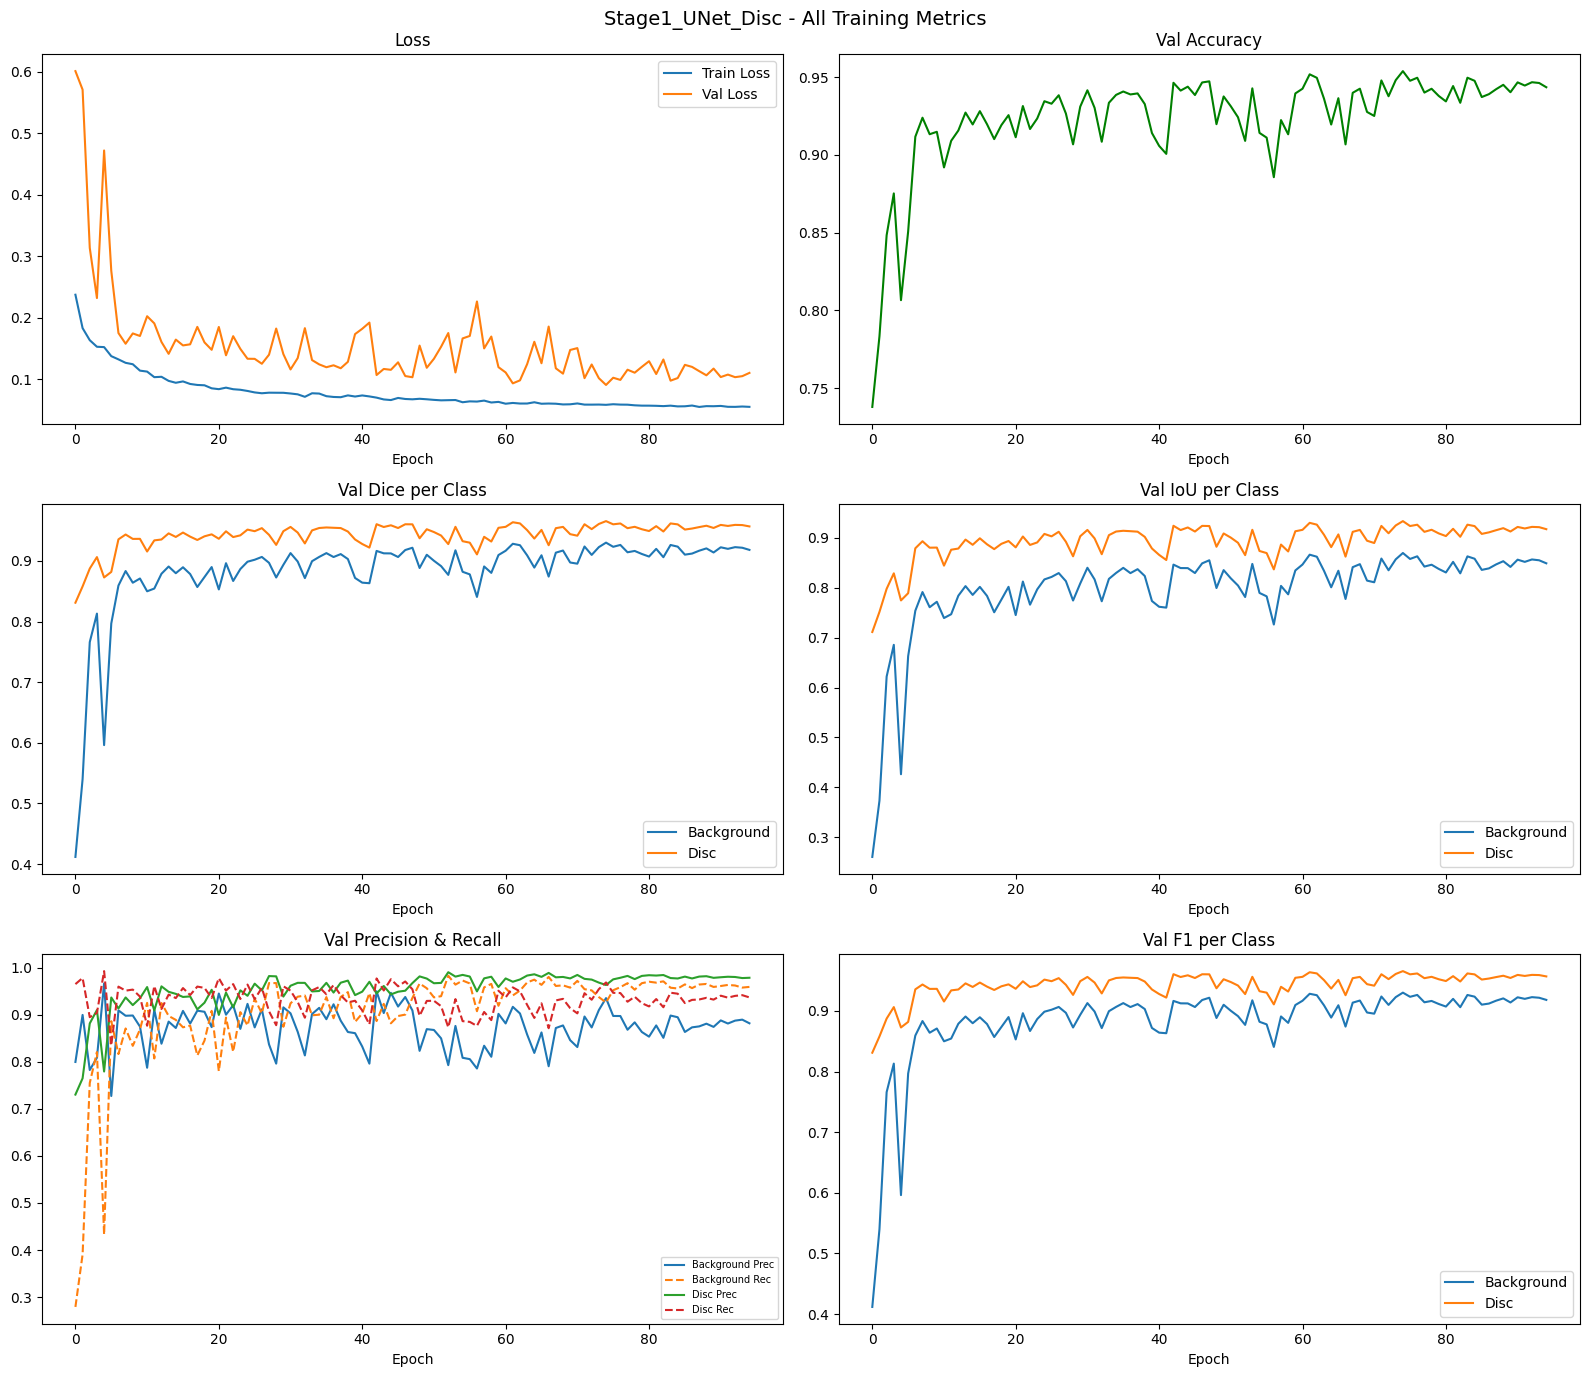


STAGE 1 TEST SET RESULTS
Test Loss: 0.0998
Accuracy:  0.9497
Dice     -> BG:0.9242 | Disc:0.9623
IoU      -> BG:0.8594  | Disc:0.9275
Precision-> BG:0.9473 | Disc:0.9508
Recall   -> BG:0.9027 | Disc:0.9743
F1       -> BG:0.9242 | Disc:0.9623


In [13]:
# Cell 11: Stage 1 curves + test evaluation
plot_all_curves(history_disc, num_classes=2, stage_name="Stage1_UNet_Disc")

# Load best checkpoint and evaluate on test set
model_disc.load_state_dict(torch.load("/content/best_unet_disc.pth"))
crit2 = CombinedLoss(2)
test_loss_disc, test_metrics_disc = evaluate_full(model_disc, test_loader_disc, crit2, DEVICE, 2)

print("\n" + "="*50)
print("STAGE 1 TEST SET RESULTS")
print("="*50)
print(f"Test Loss: {test_loss_disc:.4f}")
print(f"Accuracy:  {test_metrics_disc['accuracy']:.4f}")
print(f"Dice     -> BG:{test_metrics_disc['dice'][0]:.4f} | Disc:{test_metrics_disc['dice'][1]:.4f}")
print(f"IoU      -> BG:{test_metrics_disc['iou'][0]:.4f}  | Disc:{test_metrics_disc['iou'][1]:.4f}")
print(f"Precision-> BG:{test_metrics_disc['precision'][0]:.4f} | Disc:{test_metrics_disc['precision'][1]:.4f}")
print(f"Recall   -> BG:{test_metrics_disc['recall'][0]:.4f} | Disc:{test_metrics_disc['recall'][1]:.4f}")
print(f"F1       -> BG:{test_metrics_disc['f1'][0]:.4f} | Disc:{test_metrics_disc['f1'][1]:.4f}")

In [14]:
# Cell 12: KANLinear - same B-spline math, unchanged
class KANLinear(nn.Module):
    def __init__(self, in_features, out_features, grid_size=5, spline_order=3,
                 base_activation=nn.SiLU, grid_range=(-1,1)):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.grid_size = grid_size
        self.spline_order = spline_order
        h = (grid_range[1]-grid_range[0])/grid_size
        grid = torch.arange(-spline_order, grid_size+spline_order+1)*h + grid_range[0]
        self.register_buffer("grid", grid.expand(in_features,-1).contiguous())
        self.base_weight = nn.Parameter(torch.empty(out_features, in_features))
        self.spline_weight = nn.Parameter(torch.empty(out_features, in_features, grid_size+spline_order))
        self.base_activation = base_activation()
        nn.init.kaiming_uniform_(self.base_weight, a=math.sqrt(5))
        nn.init.normal_(self.spline_weight, mean=0.0, std=0.1)

    def b_splines(self, x):
        grid = self.grid
        x = x.unsqueeze(-1)
        bases = ((x >= grid[:,:-1]) & (x < grid[:,1:])).float()
        for k in range(1, self.spline_order+1):
            left  = (x - grid[:,  :-(k+1)]) / (grid[:, k:-1]   - grid[:,  :-(k+1)])
            right = (grid[:, k+1:]  - x)    / (grid[:, k+1:]   - grid[:, 1:-k])
            bases = left*bases[:,:,:-1] + right*bases[:,:,1:]
        return bases

    def forward(self, x):
        orig = x.shape
        x = x.reshape(-1, self.in_features)
        base_out = F.linear(self.base_activation(x), self.base_weight)
        spline_out = torch.einsum("bik,oik->bo", self.b_splines(x), self.spline_weight)
        return (base_out + spline_out).reshape(*orig[:-1], self.out_features)

In [15]:
# Cell 13: DW_bn_relu, KANLayer (3xKAN+3xDWConv, matches official repo), KANBlock
class DW_bn_relu(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dwconv = nn.Conv2d(dim, dim, 3, 1, 1, bias=True, groups=dim)
        self.bn = nn.BatchNorm2d(dim)
        self.relu = nn.ReLU()
    def forward(self, x, H, W):
        B,N,C = x.shape
        x = x.transpose(1,2).view(B,C,H,W)
        x = self.relu(self.bn(self.dwconv(x)))
        return x.flatten(2).transpose(1,2)


class KANLayer(nn.Module):
    """Official repo structure: fc1->dw1->fc2->dw2->fc3->dw3"""
    def __init__(self, in_features, hidden_features=None, drop=0.):
        super().__init__()
        hidden_features = hidden_features or in_features
        self.fc1 = KANLinear(in_features, hidden_features)
        self.fc2 = KANLinear(hidden_features, hidden_features)
        self.fc3 = KANLinear(hidden_features, in_features)
        self.dwconv_1 = DW_bn_relu(hidden_features)
        self.dwconv_2 = DW_bn_relu(hidden_features)
        self.dwconv_3 = DW_bn_relu(in_features)
        self.drop = nn.Dropout(drop)

    def forward(self, x, H, W):
        B,N,C = x.shape
        x = self.fc1(x.reshape(B*N,C)).reshape(B,N,-1)
        x = self.dwconv_1(x, H, W)
        x = self.fc2(x.reshape(B*N,x.shape[-1])).reshape(B,N,-1)
        x = self.dwconv_2(x, H, W)
        x = self.fc3(x.reshape(B*N,x.shape[-1])).reshape(B,N,-1)
        x = self.dwconv_3(x, H, W)
        return self.drop(x)


class KANBlock(nn.Module):
    def __init__(self, dim, drop=0., drop_path=0.):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.drop_path = DropPath(drop_path) if drop_path > 0. else nn.Identity()
        self.layer = KANLayer(in_features=dim, hidden_features=dim, drop=drop)

    def forward(self, x, H, W):
        return x + self.drop_path(self.layer(self.norm(x), H, W))

In [16]:
# Cell 14: ConvLayer, D_ConvLayer, PatchEmbed matching official repo
class ConvLayer(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.conv(x)

class D_ConvLayer(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, in_ch, 3, padding=1), nn.BatchNorm2d(in_ch), nn.ReLU(inplace=True),
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.conv(x)

class PatchEmbed(nn.Module):
    def __init__(self, img_size=64, patch_size=3, stride=2, in_chans=256, embed_dim=320):
        super().__init__()
        img_size = to_2tuple(img_size); patch_size = to_2tuple(patch_size)
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=stride,
                               padding=(patch_size[0]//2, patch_size[1]//2))
        self.norm = nn.LayerNorm(embed_dim)
    def forward(self, x):
        x = self.proj(x)
        _,_,H,W = x.shape
        x = x.flatten(2).transpose(1,2)
        return self.norm(x), H, W

In [17]:
# Cell 15: U-KAN matching official archs.py exactly
class UKAN(nn.Module):
    def __init__(self, num_classes=2, input_channels=4, img_size=256,
                 embed_dims=[256,320,512], drop_rate=0., drop_path_rate=0.1):
        super().__init__()
        C = embed_dims[0]
        self.encoder1 = ConvLayer(input_channels, C//8)
        self.encoder2 = ConvLayer(C//8, C//4)
        self.encoder3 = ConvLayer(C//4, C)

        self.norm3  = nn.LayerNorm(embed_dims[1])
        self.norm4  = nn.LayerNorm(embed_dims[2])
        self.dnorm3 = nn.LayerNorm(embed_dims[1])
        self.dnorm4 = nn.LayerNorm(embed_dims[0])

        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, 2)]
        self.block1  = nn.ModuleList([KANBlock(embed_dims[1], drop=drop_rate, drop_path=dpr[0])])
        self.block2  = nn.ModuleList([KANBlock(embed_dims[2], drop=drop_rate, drop_path=dpr[1])])
        self.dblock1 = nn.ModuleList([KANBlock(embed_dims[1], drop=drop_rate, drop_path=dpr[0])])
        self.dblock2 = nn.ModuleList([KANBlock(embed_dims[0], drop=drop_rate, drop_path=dpr[1])])

        self.patch_embed3 = PatchEmbed(img_size//4,  3, 2, embed_dims[0], embed_dims[1])
        self.patch_embed4 = PatchEmbed(img_size//8,  3, 2, embed_dims[1], embed_dims[2])

        self.decoder1 = D_ConvLayer(embed_dims[2], embed_dims[1])
        self.decoder2 = D_ConvLayer(embed_dims[1], embed_dims[0])
        self.decoder3 = D_ConvLayer(embed_dims[0], embed_dims[0]//4)
        self.decoder4 = D_ConvLayer(embed_dims[0]//4, embed_dims[0]//8)
        self.decoder5 = D_ConvLayer(embed_dims[0]//8, embed_dims[0]//8)
        self.final    = nn.Conv2d(embed_dims[0]//8, num_classes, 1)

    def forward(self, x):
        B = x.shape[0]
        out = F.relu(F.max_pool2d(self.encoder1(x), 2, 2)); t1 = out
        out = F.relu(F.max_pool2d(self.encoder2(out), 2, 2)); t2 = out
        out = F.relu(F.max_pool2d(self.encoder3(out), 2, 2)); t3 = out

        out,H,W = self.patch_embed3(out)
        for blk in self.block1: out = blk(out, H, W)
        out = self.norm3(out)
        out = out.reshape(B,H,W,-1).permute(0,3,1,2).contiguous(); t4 = out

        out,H,W = self.patch_embed4(out)
        for blk in self.block2: out = blk(out, H, W)
        out = self.norm4(out)
        out = out.reshape(B,H,W,-1).permute(0,3,1,2).contiguous()

        out = F.relu(F.interpolate(self.decoder1(out), scale_factor=2, mode='bilinear', align_corners=True))
        out = torch.add(out, t4)
        _,_,H,W = out.shape
        out = out.flatten(2).transpose(1,2)
        for blk in self.dblock1: out = blk(out, H, W)

        out = self.dnorm3(out).reshape(B,H,W,-1).permute(0,3,1,2).contiguous()
        out = F.relu(F.interpolate(self.decoder2(out), scale_factor=2, mode='bilinear', align_corners=True))
        out = torch.add(out, t3)
        _,_,H,W = out.shape
        out = out.flatten(2).transpose(1,2)
        for blk in self.dblock2: out = blk(out, H, W)

        out = self.dnorm4(out).reshape(B,H,W,-1).permute(0,3,1,2).contiguous()
        out = F.relu(F.interpolate(self.decoder3(out), scale_factor=2, mode='bilinear', align_corners=True))
        out = torch.add(out, t2)
        out = F.relu(F.interpolate(self.decoder4(out), scale_factor=2, mode='bilinear', align_corners=True))
        out = torch.add(out, t1)
        out = F.relu(F.interpolate(self.decoder5(out), scale_factor=2, mode='bilinear', align_corners=True))
        return self.final(out)

# Sanity check
dummy_ukan = UKAN(num_classes=2, input_channels=4).to(DEVICE)
print("UKAN output:", dummy_ukan(torch.randn(2,4,256,256).to(DEVICE)).shape)
print("UKAN params:", sum(p.numel() for p in dummy_ukan.parameters() if p.requires_grad))
del dummy_ukan

UKAN output: torch.Size([2, 2, 256, 256])
UKAN params: 23762146


In [18]:
# Cell 16: Bridge with all 3 fixes:
# FIX 1: margin=1.3 crop with minimum crop size guarantee
# FIX 2: anatomical constraint (cup must be inside disc)
# FIX 3: quality check - skip crops with < 50 disc pixels

def get_disc_bbox(disc_mask, margin=1.3, min_size=80):
    """Get bounding box around disc with margin, guaranteed minimum size."""
    ys, xs = np.where(disc_mask > 0)
    if len(ys) < 50:  # too few disc pixels = bad prediction, use full image
        H, W = disc_mask.shape
        return 0, 0, H, W
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()
    cy, cx = (y0+y1)//2, (x0+x1)//2
    half = max(int(max(y1-y0, x1-x0)*margin/2), min_size//2)
    H, W = disc_mask.shape
    return max(0,cy-half), max(0,cx-half), min(H,cy+half), min(W,cx+half)


def build_stage2_dataset(disc_model, dataset, device, crop_size=256):
    """Build Stage 2 inputs: cropped 4-channel (RGB + disc mask) + cup binary label."""
    disc_model.eval()
    inputs, cup_labels = [], []
    mean = np.array([0.485,0.456,0.406])
    std  = np.array([0.229,0.224,0.225])

    with torch.no_grad():
        for i in range(len(dataset)):
            image, mask3 = dataset[i]
            inp = image.unsqueeze(0).to(device)
            disc_pred = torch.argmax(disc_model(inp), dim=1).squeeze(0).cpu().numpy()

            y0,x0,y1,x1 = get_disc_bbox(disc_pred)
            img_np = (image.permute(1,2,0).cpu().numpy()*std + mean).clip(0,1)

            img_crop   = cv2.resize(img_np[y0:y1, x0:x1], (crop_size, crop_size))
            disc_crop  = cv2.resize(disc_pred[y0:y1, x0:x1].astype(np.uint8), (crop_size, crop_size), cv2.INTER_NEAREST)
            mask3_crop = cv2.resize(mask3.numpy()[y0:y1, x0:x1].astype(np.uint8), (crop_size, crop_size), cv2.INTER_NEAREST)

            cup_binary = (mask3_crop == 2).astype(np.int64)   # ground truth cup in crop space

            # Build 4-channel input: normalized RGB + disc mask channel
            img_normed = (img_crop - mean) / std
            combined = np.concatenate([img_normed.astype(np.float32),
                                       disc_crop[...,None].astype(np.float32)], axis=2)
            inputs.append(combined)
            cup_labels.append(cup_binary)

        print(f"Built {len(inputs)} samples")
    return inputs, cup_labels


class Stage2Dataset(Dataset):
    def __init__(self, inputs, labels):
        self.inputs, self.labels = inputs, labels
    def __len__(self): return len(self.inputs)
    def __getitem__(self, idx):
        x = torch.from_numpy(self.inputs[idx]).permute(2,0,1)
        y = torch.from_numpy(self.labels[idx]).long()
        return x, y


# Load best Stage 1 model
model_disc.load_state_dict(torch.load("/content/best_unet_disc.pth")); model_disc.eval()

print("Building Stage 2 datasets...")
train_in, train_lab = build_stage2_dataset(model_disc, train_ds, DEVICE)
val_in,   val_lab   = build_stage2_dataset(model_disc, val_ds,   DEVICE)
test_in,  test_lab  = build_stage2_dataset(model_disc, test_ds,  DEVICE)

train_ds_cup = Stage2Dataset(train_in, train_lab)
val_ds_cup   = Stage2Dataset(val_in,   val_lab)
test_ds_cup  = Stage2Dataset(test_in,  test_lab)

train_loader_cup = DataLoader(train_ds_cup, batch_size=8, shuffle=True,  num_workers=2)
val_loader_cup   = DataLoader(val_ds_cup,   batch_size=8, shuffle=False, num_workers=2)
test_loader_cup  = DataLoader(test_ds_cup,  batch_size=8, shuffle=False, num_workers=2)

imgs, masks = next(iter(train_loader_cup))
print("Stage2 batch:", imgs.shape, masks.shape, "| unique:", torch.unique(masks))

Building Stage 2 datasets...
Built 400 samples
Built 400 samples
Built 400 samples
Stage2 batch: torch.Size([8, 4, 256, 256]) torch.Size([8, 256, 256]) | unique: tensor([0, 1])


In [19]:
# Cell 17: Train Stage 2 - U-KAN cup (patience=25, more epochs)
model_cup = UKAN(num_classes=2, input_channels=4, img_size=256).to(DEVICE)
print("UKAN params:", sum(p.numel() for p in model_cup.parameters() if p.requires_grad))

history_cup = train_model(model_cup, train_loader_cup, val_loader_cup,
                           num_classes=2, num_epochs=150, patience=25, lr=1e-3,
                           save_path="/content/best_ukan_cup.pth",
                           stage_name="Stage2 UKAN Cup")

UKAN params: 23762146

Training Stage2 UKAN Cup
Ep   1/150 | TrLoss:0.2694 | ValLoss:0.2717 | Acc:0.9052 | Dice:[0.94  0.766] | Prec:[0.985 0.652] | Rec:[0.9   0.937] | F1:[0.94  0.766] | IoU:[0.888 0.622] | FGDice:0.7659
  -> Best saved (0.7659)
Ep   2/150 | TrLoss:0.1696 | ValLoss:0.2939 | Acc:0.8787 | Dice:[0.922 0.722] | Prec:[0.988 0.586] | Rec:[0.865 0.95 ] | F1:[0.922 0.722] | IoU:[0.856 0.567] | FGDice:0.7224
Ep   3/150 | TrLoss:0.1505 | ValLoss:0.2159 | Acc:0.9084 | Dice:[0.943 0.762] | Prec:[0.974 0.674] | Rec:[0.915 0.881] | F1:[0.943 0.762] | IoU:[0.893 0.616] | FGDice:0.7616
Ep   4/150 | TrLoss:0.1412 | ValLoss:0.1699 | Acc:0.9278 | Dice:[0.956 0.797] | Prec:[0.968 0.756] | Rec:[0.944 0.85 ] | F1:[0.956 0.797] | IoU:[0.916 0.665] | FGDice:0.7974
  -> Best saved (0.7974)
Ep   5/150 | TrLoss:0.1342 | ValLoss:0.2366 | Acc:0.8878 | Dice:[0.928 0.737] | Prec:[0.985 0.611] | Rec:[0.878 0.939] | F1:[0.928 0.737] | IoU:[0.867 0.585] | FGDice:0.7369
Ep   6/150 | TrLoss:0.1320 | Val

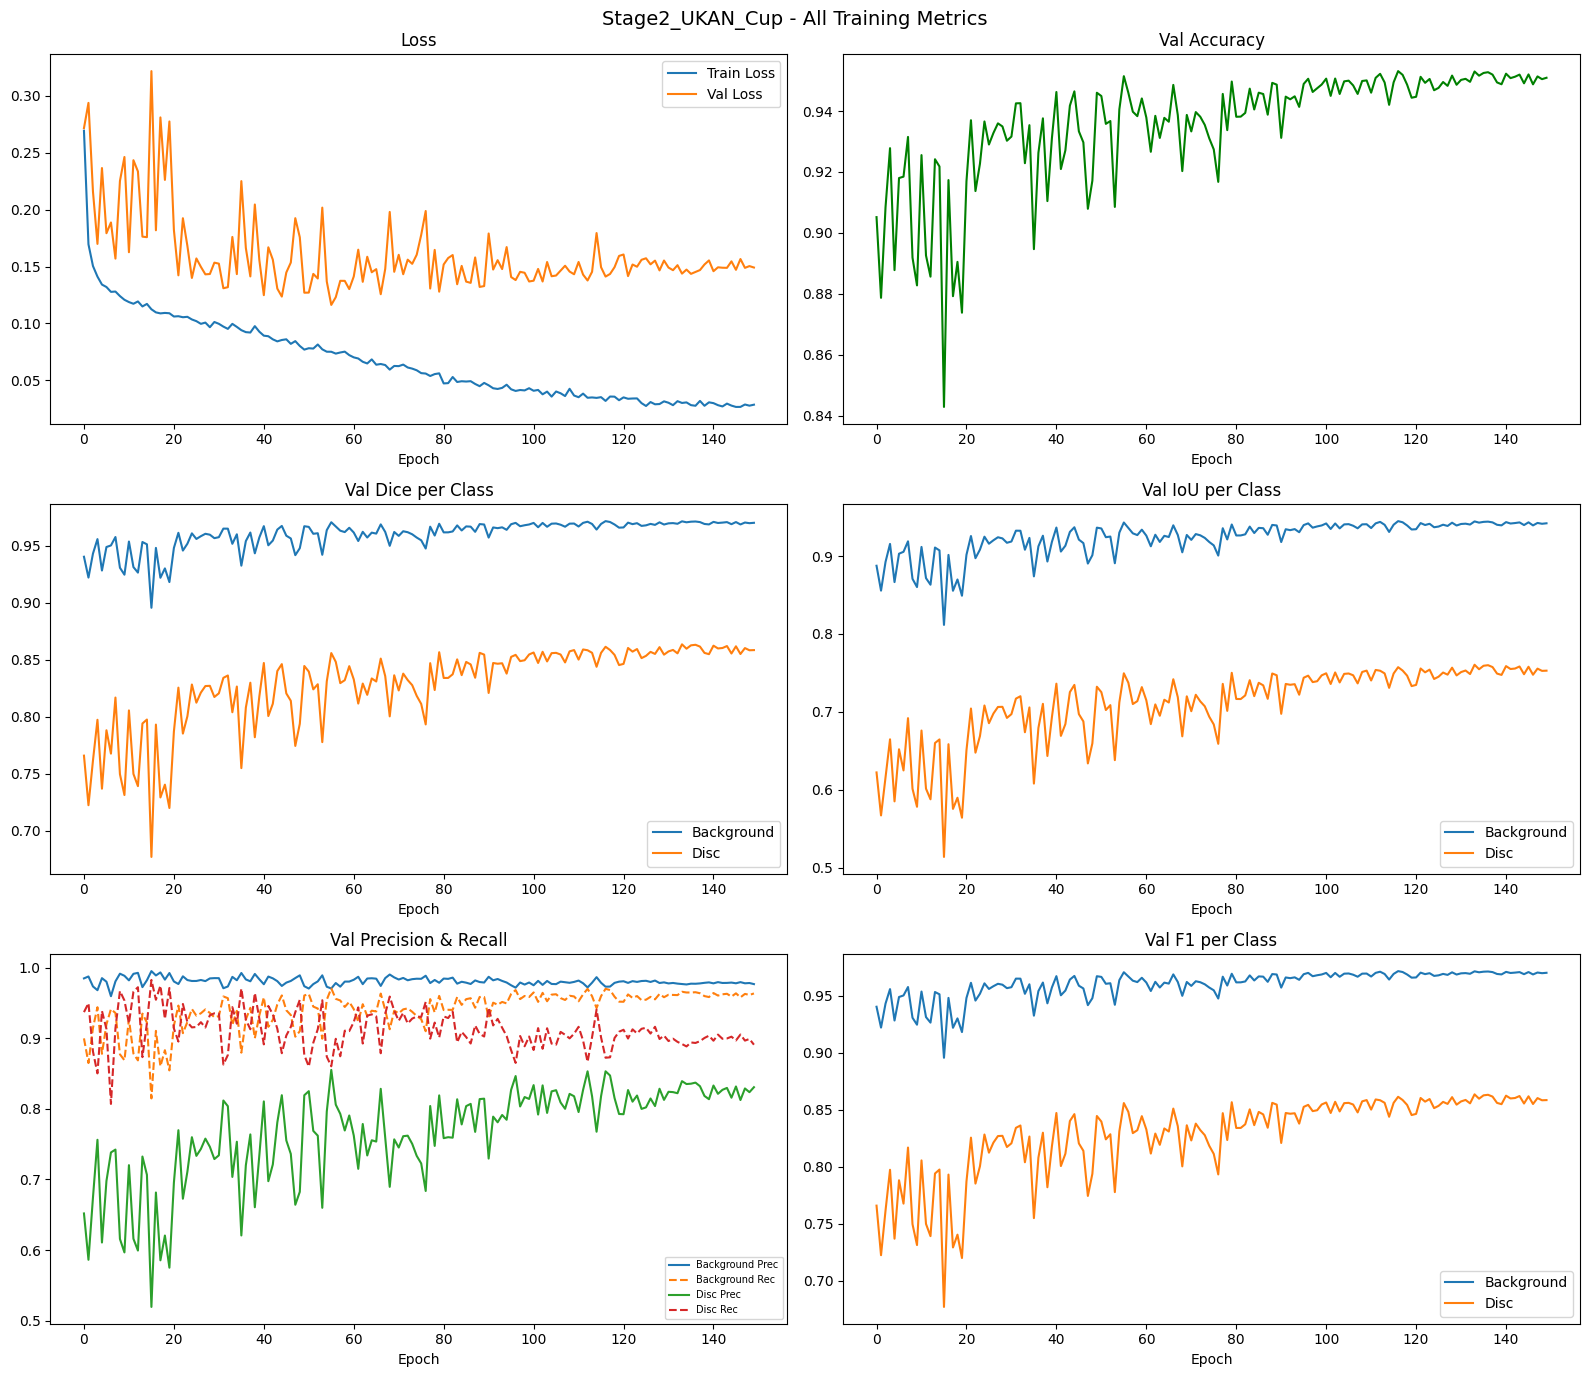


STAGE 2 TEST SET RESULTS (CUP IN CROP SPACE)
Test Loss: 0.1725
Accuracy:  0.9448
Dice     -> BG:0.9662  | Cup:0.8465
IoU      -> BG:0.9348   | Cup:0.7345
Precision-> BG:0.9759 | Cup:0.8093
Recall   -> BG:0.9569 | Cup:0.8909
F1       -> BG:0.9662    | Cup:0.8465


In [20]:
# Cell 18: Stage 2 curves + test evaluation
plot_all_curves(history_cup, num_classes=2, stage_name="Stage2_UKAN_Cup")

model_cup.load_state_dict(torch.load("/content/best_ukan_cup.pth"))
crit2 = CombinedLoss(2)
test_loss_cup, test_metrics_cup = evaluate_full(model_cup, test_loader_cup, crit2, DEVICE, 2)

print("\n" + "="*50)
print("STAGE 2 TEST SET RESULTS (CUP IN CROP SPACE)")
print("="*50)
print(f"Test Loss: {test_loss_cup:.4f}")
print(f"Accuracy:  {test_metrics_cup['accuracy']:.4f}")
print(f"Dice     -> BG:{test_metrics_cup['dice'][0]:.4f}  | Cup:{test_metrics_cup['dice'][1]:.4f}")
print(f"IoU      -> BG:{test_metrics_cup['iou'][0]:.4f}   | Cup:{test_metrics_cup['iou'][1]:.4f}")
print(f"Precision-> BG:{test_metrics_cup['precision'][0]:.4f} | Cup:{test_metrics_cup['precision'][1]:.4f}")
print(f"Recall   -> BG:{test_metrics_cup['recall'][0]:.4f} | Cup:{test_metrics_cup['recall'][1]:.4f}")
print(f"F1       -> BG:{test_metrics_cup['f1'][0]:.4f}    | Cup:{test_metrics_cup['f1'][1]:.4f}")

In [22]:
# Cell 19: Combine Stage1 + Stage2 with all fixes, evaluate full 3-class
model_disc.load_state_dict(torch.load("/content/best_unet_disc.pth")); model_disc.eval()
model_cup.load_state_dict(torch.load("/content/best_ukan_cup.pth")); model_cup.eval()

MEAN = np.array([0.485,0.456,0.406])
STD  = np.array([0.229,0.224,0.225])

def post_process_mask(mask, min_size=200):
    """FIX 2: Largest connected component + morphological closing for smooth boundaries."""
    if mask.max() == 0: return mask
    labeled, n = ndimage.label(mask)
    if n == 0: return mask
    sizes = ndimage.sum(mask, labeled, range(1, n+1))
    largest = np.argmax(sizes)+1
    clean = (labeled == largest).astype(np.uint8)
    # Morphological closing: fills gaps, smooths boundary
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
    clean = cv2.morphologyEx(clean, cv2.MORPH_CLOSE, kernel)
    return clean

@torch.no_grad()
def predict_combined(image_tensor):
    """Full W-Net pipeline: Stage1 disc -> crop -> Stage2 cup -> combine with anatomical constraint."""
    inp = image_tensor.unsqueeze(0).to(DEVICE)

    # Stage 1: predict disc
    disc_pred = torch.argmax(model_disc(inp), dim=1).squeeze(0).cpu().numpy()
    disc_pred = post_process_mask(disc_pred)  # clean disc boundary

    # Get crop bbox
    y0,x0,y1,x1 = get_disc_bbox(disc_pred)
    img_np = (image_tensor.permute(1,2,0).cpu().numpy()*STD + MEAN).clip(0,1)

    # Crop and normalize for Stage 2
    img_crop  = cv2.resize(img_np[y0:y1, x0:x1], (256,256))
    disc_crop = cv2.resize(disc_pred[y0:y1, x0:x1].astype(np.uint8), (256,256), cv2.INTER_NEAREST)
    img_normed = (img_crop - MEAN) / STD
    combined = np.concatenate([img_normed.astype(np.float32), disc_crop[...,None].astype(np.float32)], axis=2)
    combined_t = torch.from_numpy(combined).permute(2,0,1).unsqueeze(0).to(DEVICE)

    # Stage 2: predict cup in crop space
    cup_crop = torch.argmax(model_cup(combined_t), dim=1).squeeze(0).cpu().numpy()
    cup_crop = post_process_mask(cup_crop)   # clean cup boundary

    # Warp cup back to full 256x256 space
    full_cup = np.zeros_like(disc_pred)
    cup_back = cv2.resize(cup_crop.astype(np.uint8), (x1-x0, y1-y0), cv2.INTER_NEAREST)
    full_cup[y0:y1, x0:x1] = cup_back

    # FIX 3: Anatomical constraint — cup must be inside disc
    full_cup = full_cup & disc_pred   # only keep cup where disc was predicted

    # Combine: start with disc, overlay cup
    final = disc_pred.copy().astype(np.uint8)   # 0=bg, 1=disc
    final[full_cup == 1] = 2                     # 2=cup (inside disc only)
    return final

print("Combine + post-process ready.")

Combine + post-process ready.


In [23]:
# Cell 20: Full 3-class evaluation on test set
def evaluate_combined_full(dataset):
    agg = {k: np.zeros(3) for k in ["dice","iou","precision","recall","f1"]}
    agg["accuracy"] = 0.0
    n = len(dataset)
    smooth = 1e-6

    for i in range(n):
        image, mask3_gt = dataset[i]
        pred = predict_combined(image)
        gt   = mask3_gt.numpy()

        for c in range(3):
            pred_c  = (pred==c)
            gt_c    = (gt==c)
            tp = (pred_c & gt_c).sum()
            fp = (pred_c & ~gt_c).sum()
            fn = (~pred_c & gt_c).sum()
            prec = (tp+smooth)/(tp+fp+smooth)
            rec  = (tp+smooth)/(tp+fn+smooth)
            dice = (2*tp+smooth)/(2*tp+fp+fn+smooth)
            iou  = (tp+smooth)/(tp+fp+fn+smooth)
            f1   = (2*prec*rec)/(prec+rec+smooth)
            agg["dice"][c]      += dice
            agg["iou"][c]       += iou
            agg["precision"][c] += prec
            agg["recall"][c]    += rec
            agg["f1"][c]        += f1
        agg["accuracy"] += (pred==gt).mean()

    for k in agg: agg[k] = agg[k]/n

    names = ["Background","Disc","Cup"]
    print("\n" + "="*60)
    print("FINAL COMBINED W-NET TEST RESULTS (3-CLASS)")
    print("="*60)
    print(f"Accuracy: {agg['accuracy']:.4f}")
    for k in ["dice","iou","precision","recall","f1"]:
        vals = "  |  ".join([f"{names[c]}: {agg[k][c]:.4f}" for c in range(3)])
        print(f"{k.upper():10s}: {vals}")
    print(f"\nMean Disc+Cup Dice: {(agg['dice'][1]+agg['dice'][2])/2:.4f}")
    print(f"Mean Disc+Cup IoU:  {(agg['iou'][1]+agg['iou'][2])/2:.4f}")
    print(f"Mean Disc+Cup F1:   {(agg['f1'][1]+agg['f1'][2])/2:.4f}")
    return agg

final_metrics = evaluate_combined_full(test_ds)


FINAL COMBINED W-NET TEST RESULTS (3-CLASS)
Accuracy: 0.8945
DICE      : Background: 0.9241  |  Disc: 0.8873  |  Cup: 0.8433
IOU       : Background: 0.8616  |  Disc: 0.8031  |  Cup: 0.7341
PRECISION : Background: 0.9502  |  Disc: 0.8863  |  Cup: 0.7997
RECALL    : Background: 0.9035  |  Disc: 0.8930  |  Cup: 0.9163
F1        : Background: 0.9241  |  Disc: 0.8873  |  Cup: 0.8433

Mean Disc+Cup Dice: 0.8653
Mean Disc+Cup IoU:  0.7686
Mean Disc+Cup F1:   0.8653


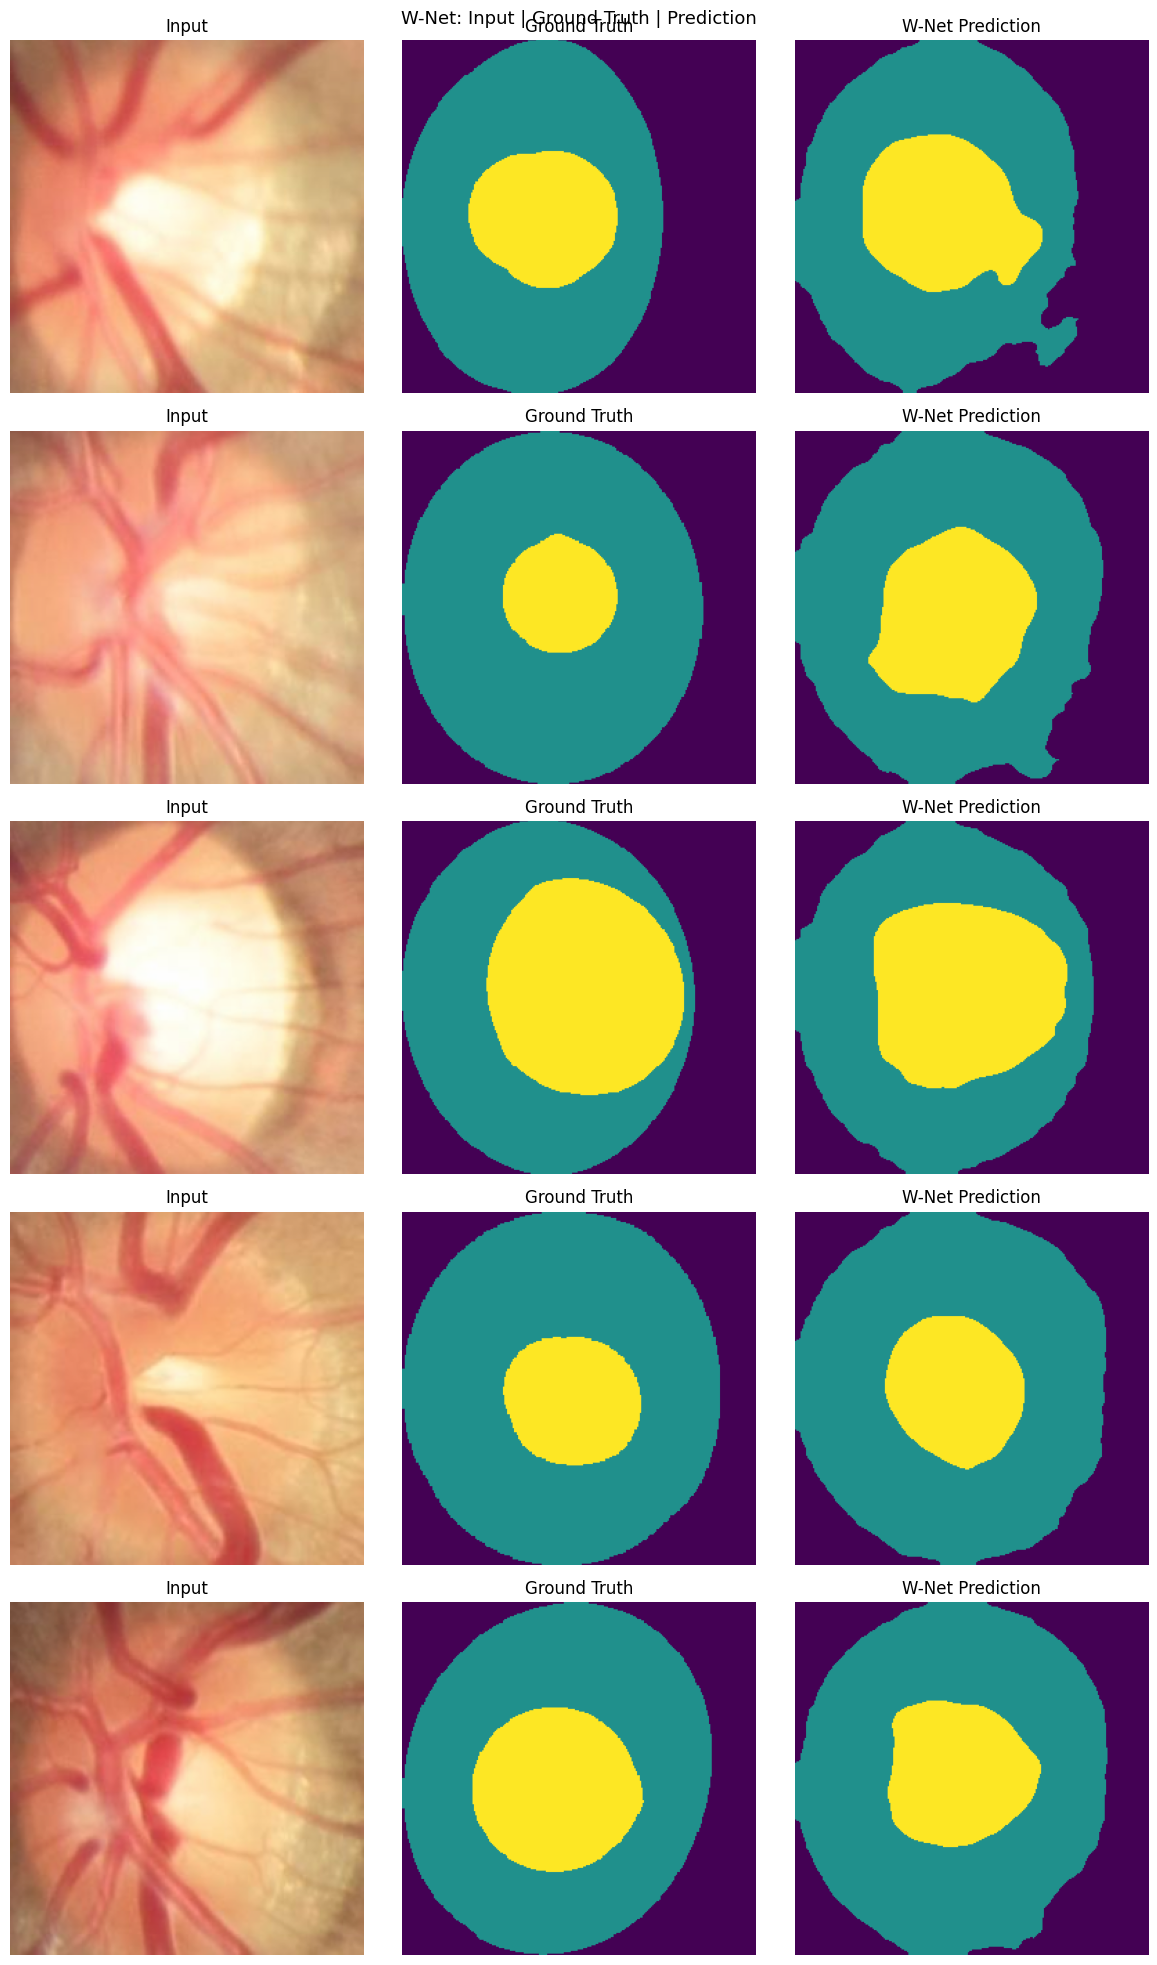

In [24]:
# Cell 21: Visualize W-Net predictions
def visualize_wnet(dataset, num_samples=5):
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4*num_samples))
    fig.suptitle("W-Net: Input | Ground Truth | Prediction", fontsize=13)
    indices = random.sample(range(len(dataset)), num_samples)
    for i, idx in enumerate(indices):
        image, mask3_gt = dataset[idx]
        pred = predict_combined(image)
        img_show = (image.permute(1,2,0).cpu().numpy()*STD + MEAN).clip(0,1)
        axes[i,0].imshow(img_show); axes[i,0].set_title("Input"); axes[i,0].axis('off')
        axes[i,1].imshow(mask3_gt.numpy(), cmap='viridis', vmin=0, vmax=2)
        axes[i,1].set_title("Ground Truth"); axes[i,1].axis('off')
        axes[i,2].imshow(pred, cmap='viridis', vmin=0, vmax=2)
        axes[i,2].set_title("W-Net Prediction"); axes[i,2].axis('off')
    plt.tight_layout()
    plt.savefig('/content/wnet_final_predictions.png', dpi=100); plt.show()

visualize_wnet(test_ds, num_samples=5)